## Execution record

Smaller local training run on 3 October 2026. Settings: {"MUSIC_STEPS": "600", "MUSIC_HIDDEN_SIZE": "256"}. Outputs below are from execution in this session. External services and audio playback may be skipped with an explicit reason.


# My music generation notebook

Adapted from [MIT Introduction to Deep Learning](http://introtodeeplearning.com). I keep its copyright notice and use its ABC music helpers. These notes explain how I prepare the sequences and train the LSTM.

In [1]:
# Copyright 2026 MIT Introduction to Deep Learning. All Rights Reserved.
#
# Licensed under the MIT License. You may not use this file except in compliance
# with the License. Use and/or modification of this code outside of MIT Introduction
# to Deep Learning must reference:
#
# © MIT Introduction to Deep Learning
# http://introtodeeplearning.com
#

## Predicting music as text

I train an LSTM to predict the next character in ABC notation. The model works with written musical symbols rather than audio waveforms.

## Runtime setup

I import the training packages and keep metrics locally. External audio playback uses abc2midi and timidity. If they are unavailable I parse the ABC with music21 and render up to eight seconds of simple sine tones at 120 quarter notes per minute. This playback is a notation check rather than a learned audio model.

In [2]:
%pip install music21 --quiet
%pip install "setuptools<81" --quiet
%pip install mitdeeplearning --no-deps --no-build-isolation --quiet
import mitdeeplearning as mdl
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
from tqdm import tqdm
torch.manual_seed(7)
np.random.seed(7)
torch.set_num_threads(4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
audio_available = bool(shutil.which("abc2midi") and shutil.which("timidity"))
print("Runtime:", device, "Audio converters available:", audio_available)
class LocalExperiment:
    """I retain metrics locally so a notebook run needs no service account."""
    def __init__(self):
        self.metrics = {}
        self.parameters = {}
    def log_parameter(self, name, value):
        self.parameters[name] = value
    def log_metric(self, name, value, step=None):
        self.metrics.setdefault(name, []).append(float(value))
    def log_figure(self, figure=None):
        pass
    def log_asset(self, path):
        pass
    def flush(self):
        pass
    def end(self):
        print("Recorded metrics:", {k: v[-1] for k, v in self.metrics.items()})

def render_abc_audio(song, rate=11025):
    """I use simple sine tones when the external ABC converters are unavailable."""
    from music21 import converter
    score = converter.parseData(song, format="abc")
    part = score.parts[0] if score.parts else score
    flat = part.flatten()
    seconds_per_quarter = 0.5
    length = int(min(8.0, float(flat.highestTime) * seconds_per_quarter + 0.25) * rate)
    signal = np.zeros(length, dtype=np.float32)
    for note in flat.notes:
        start = int(float(note.offset) * seconds_per_quarter * rate)
        if start >= length:
            continue
        duration = min(int(float(note.quarterLength) * seconds_per_quarter * rate), length - start)
        if duration <= 0:
            continue
        time = np.arange(duration) / rate
        pitches = note.pitches if hasattr(note, "pitches") else [note.pitch]
        tone = sum(np.sin(2 * np.pi * pitch.frequency * time) for pitch in pitches) / len(pitches)
        envelope = np.minimum(1.0, time / 0.01) * np.minimum(1.0, (duration / rate - time) / 0.03)
        end = min(start + duration, length)
        signal[start:end] += (0.2 * tone[:end - start] * envelope[:end - start]).astype(np.float32)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal /= peak
    return ipythondisplay.Audio(signal, rate=rate)

def play_abc(song):
    if audio_available:
        return mdl.lab1.play_song(song)
    return render_abc_audio(song)


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


C:\Users\Somil Singh\Documents\Codex\2026-10-03\new-chat\work\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Runtime: cuda Audio converters available: False


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Loading the songs

I use the course collection of ABC tunes. Looking at one song helps me distinguish headers such as key and meter from the note sequence.

In [3]:
# Download the dataset
songs = mdl.lab1.load_training_data()

# Print one of the songs to inspect it in greater detail!
example_song = songs[0]
print("\nExample song: ")
print(example_song)


Found 817 songs in text

Example song: 
X:1
T:Alexander's
Z: id:dc-hornpipe-1
M:C|
L:1/8
K:D Major
(3ABc|dAFA DFAd|fdcd FAdf|gfge fefd|(3efe (3dcB A2 (3ABc|!
dAFA DFAd|fdcd FAdf|gfge fefd|(3efe dc d2:|!
AG|FAdA FAdA|GBdB GBdB|Acec Acec|dfaf gecA|!
FAdA FAdA|GBdB GBdB|Aceg fefd|(3efe dc d2:|!


I try converting the example to audio when the converters are installed. If they are missing I use the simple sine tone renderer and retain the notation.

In [4]:
print("Example playback uses external converters:" if audio_available else "Example playback previews up to eight seconds with sine tones at 120 quarter notes per minute.")
ipythondisplay.display(play_abc(example_song))


Example playback previews up to eight seconds with sine tones at 120 quarter notes per minute.


The model has to learn musical notes as well as metadata and line structure. Valid ABC syntax is one useful check but it does not measure musical quality.

### My note on joining songs

I separate songs with two newline characters. Random training windows can cross song boundaries so that separator becomes part of the pattern the model sees.

In [5]:
# Join our list of song strings into a single string containing all songs
songs_joined = "\n\n".join(songs)

# Find all unique characters in the joined string
vocab = sorted(set(songs_joined))
print("There are", len(vocab), "unique characters in the dataset")


There are 83 unique characters in the dataset


## Preparing the prediction task

The input is a sequence of character indices and the target is the same sequence shifted forward by one character.

## My character vocabulary

I assign each unique character an integer and keep the reverse mapping for decoding generated text.

### My note on representation

ABC text gives me a compact way to practise sequence modelling. A character vocabulary avoids a complicated tokenizer but gives the model no explicit knowledge of musical timing.

In [6]:
### Define numerical representation of text ###

# Create a mapping from character to unique index.
# For example, to get the index of the character "d",
#   we can evaluate `char2idx["d"]`.
char2idx = {u: i for i, u in enumerate(vocab)}

# Create a mapping from indices to characters. This is
#   the inverse of char2idx and allows us to convert back
#   from unique index to the character in our vocabulary.
idx2char = np.array(vocab)


I print part of the mapping so I can check that whitespace and punctuation are represented alongside letters and numbers.

In [7]:
print('{')
for char, _ in zip(char2idx, range(20)):
    print('  {:4s}: {:3d},'.format(repr(char), char2idx[char]))
print('  ...\n}')


{
  '\n':   0,
  ' ' :   1,
  '!' :   2,
  '"' :   3,
  '#' :   4,
  "'" :   5,
  '(' :   6,
  ')' :   7,
  ',' :   8,
  '-' :   9,
  '.' :  10,
  '/' :  11,
  '0' :  12,
  '1' :  13,
  '2' :  14,
  '3' :  15,
  '4' :  16,
  '5' :  17,
  '6' :  18,
  '7' :  19,
  ...
}


In [8]:
### Vectorize the songs string ###

def vectorize_string(string):
    return np.array([char2idx[c] for c in string])

vectorized_songs = vectorize_string(songs_joined)


I compare the first characters with their integer indices. Decoding those indices should reproduce the original text exactly.

In [9]:
print ('{} ---- characters mapped to int ----> {}'.format(repr(songs_joined[:10]), vectorized_songs[:10]))
# check that vectorized_songs is a numpy array
assert isinstance(vectorized_songs, np.ndarray), "returned result should be a numpy array"


'X:1\nT:Alex' ---- characters mapped to int ----> [49 22 13  0 45 22 26 67 60 79]


## Creating batches

I choose random starting positions and take windows of a fixed length. Each target starts one character after its input.

In [10]:
### Batch definition to create training examples ###

def get_batch(vectorized_songs, seq_length, batch_size):
    # the length of the vectorized songs string
    n = vectorized_songs.shape[0] - 1
    # randomly choose the starting indices for the examples in the training batch
    idx = np.random.choice(n - seq_length, batch_size)

    input_batch = [vectorized_songs[i : i + seq_length] for i in idx]
    output_batch = [vectorized_songs[i + 1 : i + seq_length + 1] for i in idx]

    # Convert the input and output batches to tensors
    x_batch = torch.as_tensor(np.array(input_batch), dtype=torch.long)
    y_batch = torch.as_tensor(np.array(output_batch), dtype=torch.long)

    return x_batch, y_batch

# Perform some simple tests to make sure your batch function is working properly!
test_args = (vectorized_songs, 10, 2)
x_batch, y_batch = get_batch(*test_args)
assert x_batch.shape == (2, 10), "x_batch shape is incorrect"
assert y_batch.shape == (2, 10), "y_batch shape is incorrect"
print("Batch function works correctly!")


Batch function works correctly!


At every time step the target is the next character. The model makes a prediction for every position in the window rather than only its final character.

### My note on context length

Sequence length sets the amount of context in each training window. Longer windows may capture more structure but increase the work and memory required for each update.

In [11]:
x_batch, y_batch = get_batch(vectorized_songs, seq_length=5, batch_size=1)

for i, (input_idx, target_idx) in enumerate(zip(x_batch[0], y_batch[0])):
    print("Step {:3d}".format(i))
    print("  input: {} ({:s})".format(input_idx, repr(idx2char[input_idx.item()])))
    print("  expected output: {} ({:s})".format(target_idx, repr(idx2char[target_idx.item()])))


Step   0
  input: 82 (np.str_('|'))
  expected output: 31 (np.str_('F'))
Step   1
  input: 31 (np.str_('F'))
  expected output: 31 (np.str_('F'))
Step   2
  input: 31 (np.str_('F'))
  expected output: 31 (np.str_('F'))
Step   3
  input: 31 (np.str_('F'))
  expected output: 1 (np.str_(' '))
Step   4
  input: 1 (np.str_(' '))
  expected output: 26 (np.str_('A'))


## My LSTM model

I use an embedding layer followed by an LSTM and a linear projection into the character vocabulary.

The embedding converts character indices into learned vectors. The recurrent state carries information through the sequence and the final projection returns logits.

## Defining the layers

I set batch_first to True so the model uses batch then sequence then feature dimensions.

### My note on the recurrent state

The LSTM keeps a hidden state and a cell state. I initialise both with zeros for independent training windows and carry them forward during generation.

In [12]:
### Defining the RNN Model ###

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size

        # Define each of the network layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def init_hidden(self, batch_size, device):
        # Initialize hidden state and cell state with zeros
        return (torch.zeros(1, batch_size, self.hidden_size).to(device),
                torch.zeros(1, batch_size, self.hidden_size).to(device))

    def forward(self, x, state=None, return_state=False):
        x = self.embedding(x)

        if state is None:
            state = self.init_hidden(x.size(0), x.device)
        out, state = self.lstm(x, state)

        out = self.fc(out)
        return out if not return_state else (out, state)



I instantiate the model and print its layers before training. That lets me check vocabulary size and hidden dimensions.

In [13]:
# Instantiate the model! Build a simple model with default hyperparameters. You
#     will get the chance to change these later.
vocab_size = len(vocab)
embedding_dim = 256
hidden_size = int(os.getenv("MUSIC_HIDDEN_SIZE", "1024"))
batch_size = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(vocab_size, embedding_dim, hidden_size).to(device)

# print out a summary of the model
print(model)


LSTMModel(
  (embedding): Embedding(83, 256)
  (lstm): LSTM(256, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=83, bias=True)
)

## Checking tensor shapes

I send a sample batch through the untrained network. Its output should have one vocabulary score vector for every character position.

In [14]:
# Test the model with some sample data
x, y = get_batch(vectorized_songs, seq_length=100, batch_size=32)
x = x.to(device)
y = y.to(device)

pred = model(x)
print("Input shape:      ", x.shape, " # (batch_size, sequence_length)")
print("Prediction shape: ", pred.shape, "# (batch_size, sequence_length, vocab_size)")


Input shape:      

 torch.Size([32, 100])  # (batch_size, sequence_length)
Prediction shape:  torch.Size([32, 100, 83]) # (batch_size, sequence_length, vocab_size)


## Sampling before training

I sample from the untrained logits to see the starting behaviour. This is a shape and decoding check rather than useful music.

In [15]:
sampled_indices = torch.multinomial(torch.softmax(pred[0], dim=-1), num_samples=1)
sampled_indices = sampled_indices.squeeze(-1).cpu().numpy()
sampled_indices


array([49, 37, 10, 79, 49, 54, 66, 59, 57, 62, 76, 24,  2, 26, 48, 17, 13,
       35, 44, 24, 52, 71, 62, 41, 38, 24,  3, 80, 42, 20, 46, 64, 32, 66,
        5, 51, 74, 41,  6, 29, 71, 64,  3, 41, 44, 24, 31, 16, 72, 31, 28,
       64, 45, 46, 46, 69, 31, 67, 25, 77, 69, 45, 19, 54, 43, 21, 12, 15,
       81,  4, 16, 70, 33, 42, 78, 31, 80, 49, 70, 35, 55,  5, 36, 75, 12,
       65, 63, 59, 39,  7, 42, 30, 55, 58, 47, 31, 54, 79, 62,  3])

I decode the sampled indices back into text and compare them with the input window.

In [16]:
print("Input: \n", repr("".join(idx2char[x[0].cpu()])))
print()
print("Next Char Predictions: \n", repr("".join(idx2char[sampled_indices])))


Input: 
 "X:41\nT:Murphy's\nZ: id:dc-hornpipe-37\nM:C|\nL:1/8\nK:D Major\n(3ABc|d2AF d2AF|dcdf ecAg|fgaf gfed|c2A2 A"

Next Char Predictions: 
 'XL.xX^kdbgu=!AW51JS=[pgPM="yQ8UiGk\'ZsP(Dpi"PS=F4qFCiTUUnFl>vnT7^R903z#4oHQwFyXoJ_\'Kt0jhdN)QE_cVF^xg"'


### My note on this check

A model can return correctly shaped tensors while predicting nonsense. Looking at the decoded output makes that distinction visible.

Training should make the character predictions more consistent with the corpus. I inspect the loss and generated text rather than assuming that a longer run must sound better.

## Training objective

I use cross entropy over every character position. The network returns logits and the loss handles their normalisation.

### My note on reshaping

I flatten batch and sequence dimensions for the loss while leaving vocabulary size as the class dimension. The target indices must follow the same order.

In [17]:
### Defining the loss function ###

cross_entropy = nn.CrossEntropyLoss() # instantiates the function
def compute_loss(labels, logits):
    """
    Inputs:
      labels: (batch_size, sequence_length)
      logits: (batch_size, sequence_length, vocab_size)

    Output:
      loss: scalar cross entropy loss over the batch and sequence length
    """

    # Batch the labels so that the shape of the labels should be (B * L,)
    batched_labels = labels.view(-1)

    # Batch the logits so that the shape of the logits should be (B * L, V)
    batched_logits = logits.view(-1, logits.size(-1))

    # Compute the cross entropy loss
    loss = cross_entropy(batched_logits, batched_labels)
    return loss


In [18]:
### compute the loss on the predictions from the untrained model from earlier. ###
y.shape  # (batch_size, sequence_length)
pred.shape  # (batch_size, sequence_length, vocab_size)

example_batch_loss = compute_loss(y, pred)

print(f"Prediction shape: {pred.shape} # (batch_size, sequence_length, vocab_size)")
print(f"scalar_loss:      {example_batch_loss.mean().item()}")


Prediction shape: torch.Size([32, 100, 83]) # (batch_size, sequence_length, vocab_size)
scalar_loss:      4.398941516876221


## Run settings

I print the iteration count and model dimensions used for this run. Environment overrides allow a smaller local experiment while keeping the full settings available.

In [19]:
### Hyperparameter setting and optimization ###

vocab_size = len(vocab)

# Model parameters:
params = dict(
  num_training_iterations = int(os.getenv("MUSIC_STEPS", "3000")),  # Increase this to train longer
  batch_size = 8,  # Experiment between 1 and 64
  seq_length = 100,  # Experiment between 50 and 500
  learning_rate = 5e-3,  # Experiment between 1e-5 and 1e-1
  embedding_dim = 256,
  hidden_size = int(os.getenv("MUSIC_HIDDEN_SIZE", "1024")),  # Experiment between 1 and 2048
)

# Checkpoint location:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "my_ckpt")
os.makedirs(checkpoint_dir, exist_ok=True)

# note to self: seq_length here is the tradeoff knob. longer context per training example means
# the model can learn longer range musical structure, but each step gets slower and needs more memory

print("Training settings:", params)


Training settings: {'num_training_iterations': 600, 'batch_size': 8, 'seq_length': 100, 'learning_rate': 0.005, 'embedding_dim': 256, 'hidden_size': 256}


## Recording the experiment

I keep the parameters and loss history in this notebook. The local recorder avoids account setup and external uploads.

In [20]:
def create_experiment():
    experiment = LocalExperiment()
    experiment.parameters.update(params)
    return experiment


## Taking training steps

Each step clears gradients then computes the predictions and loss. I clip the gradient norm before the optimizer update to limit large recurrent gradients.

### My note on optimisation

I use Adam with the configured learning rate. I save the final loss curve and checkpoint so the displayed result is tied to the completed training run.

  0%|          | 0/600 [00:00<?, ?it/s]


  0%|          | 1/600 [00:00<02:00,  4.97it/s]


  2%|▏         | 11/600 [00:00<00:13, 43.07it/s]


Step 0 loss: 4.4205


  4%|▎         | 21/600 [00:00<00:09, 62.49it/s]


...

 94%|█████████▍| 567/600 [00:05<00:00, 98.69it/s]


 96%|█████████▋| 578/600 [00:06<00:00, 99.15it/s]


 98%|█████████▊| 589/600 [00:06<00:00, 100.01it/s]


100%|██████████| 600/600 [00:06<00:00, 99.23it/s] 


100%|██████████| 600/600 [00:06<00:00, 95.52it/s]


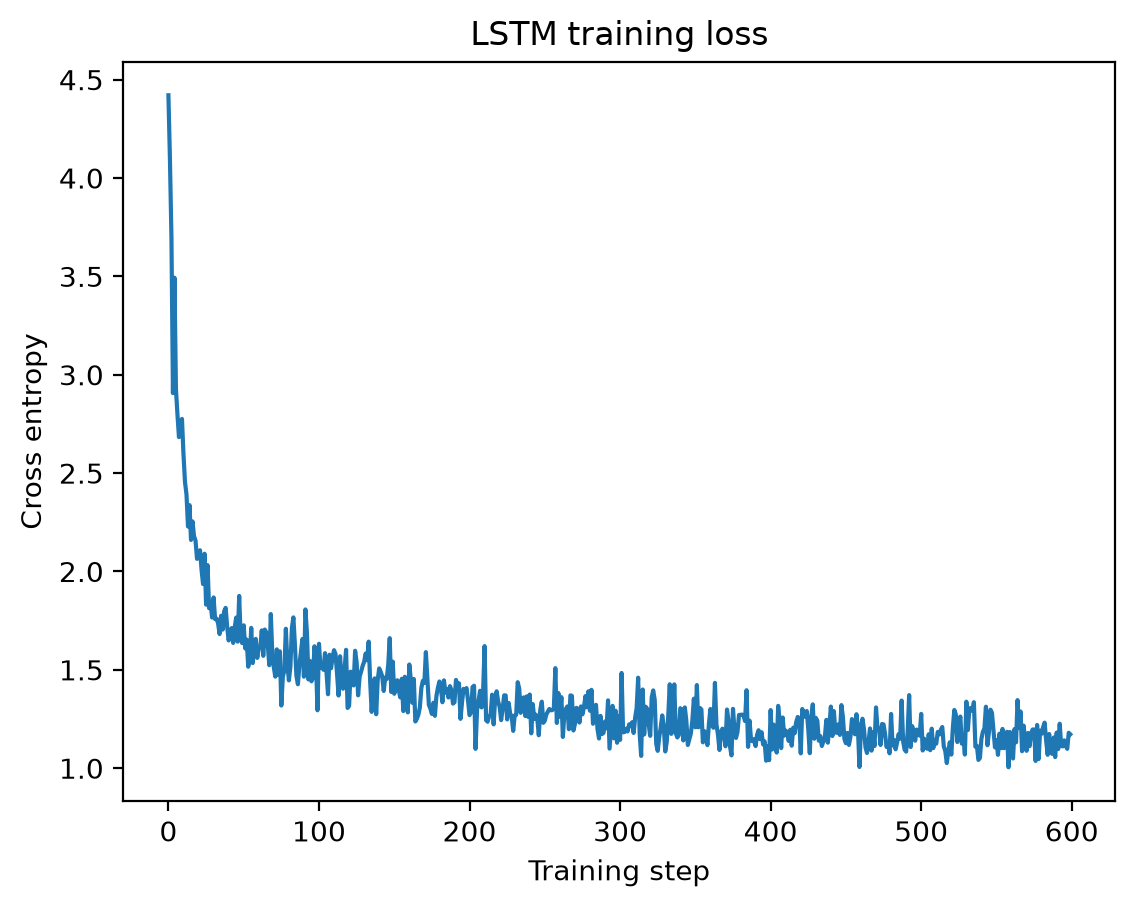

In [21]:
### Define optimizer and training operation ###

model = LSTMModel(vocab_size, params["embedding_dim"], params["hidden_size"])

# Move the model to the GPU
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"])

def train_step(x, y):
  # Set the model's mode to train
  model.train()

  # Zero gradients for every step
  optimizer.zero_grad()

  # Forward pass
  y_hat = model(x)

  # Compute the loss
  loss = compute_loss(y, y_hat)

  # Backward pass
  loss.backward()
  torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
  optimizer.step()

  return loss

##################
# Begin training!#
##################

history = []
experiment = create_experiment()

if hasattr(tqdm, '_instances'): tqdm._instances.clear() # clear if it exists
for iter in tqdm(range(params["num_training_iterations"])):

    # Grab a batch and propagate it through the network
    x_batch, y_batch = get_batch(vectorized_songs, params["seq_length"], params["batch_size"])

    # Convert numpy arrays to PyTorch tensors
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)

    # Take a train step
    loss = train_step(x_batch, y_batch)

    # Log the loss to the Comet interface
    experiment.log_metric("loss", loss.item(), step=iter)

    # Update the progress bar and visualize within notebook
    history.append(loss.item())
    if iter % 100 == 0:
        print(f"Step {iter} loss: {loss.item():.4f}")

    # Save model checkpoint
    if iter % 100 == 0:
        torch.save(model.state_dict(), checkpoint_prefix)

# Save the final trained model
torch.save(model.state_dict(), checkpoint_prefix)
experiment.flush()

plt.figure()
plt.plot(history)
plt.xlabel("Training step")
plt.ylabel("Cross entropy")
plt.title("LSTM training loss")
plt.show()


## Generating ABC text

I start with a seed and repeatedly sample the next character. The recurrent state stays connected across generation steps but gradients are disabled.

## My generation loop

I feed the seed through the model then sample from the last position. Each sampled character becomes the next input. A fixed random seed makes the run easier to compare.

In [22]:
@torch.no_grad()
def generate_text(model, start_string, generation_length=1000):
    model.eval()
    input_idx = torch.tensor([[char2idx[s] for s in start_string]], device=device)
    state = model.init_hidden(1, device)
    generated = []
    for _ in range(generation_length):
        predictions, state = model(input_idx, state, return_state=True)
        probabilities = torch.softmax(predictions[:, -1, :], dim=-1)
        input_idx = torch.multinomial(probabilities, num_samples=1)
        generated.append(idx2char[input_idx.item()])
    return start_string + ''.join(generated)


In [23]:
generated_text = generate_text(model, start_string="X", generation_length=1000)

print(generated_text)


X:10
:Funtorancy
Z: id:dc-setdance-29
M:C
L:1/8
K:G Major
AG|FGAB c2gf|edcA BGEG|D3B ADDC|[2f g2fg|!
a3f adaf|edec d2B2|BEE2 G3B|dedf e3g|efde fde2|c2B2 c2B2 c2de|fggb a2ga|bged edBG|ABAe faec|d2d^c d2:|!

X:173
T:Hughourie Erenncy's
Z: id:dc-reel-50
M:C
L:1/8
K:D Major
AG|FDD2 G,B,2C|DGAc BGG2|gfed cAGE|DEFG A2cA|!
F2FA =FDEF|GFF2 DB,ED|EFGB A2:|!

X:163
T:Free'st Sick's
Z: id:dc-setdance-6
M:C|
L:1/8
K:D Major
D3FG|A2FA dFAF|(2fgfe d2de|fdBd A2d2|f3d edBG|C2A,2 CDA,2|!B,G,B,B, D2:|!

X:210
T:Tridmoy Tamy
Z: id:dc-reel-49
M:C
L:1/8
K:D Major
f|edec B3A|B2Bd Bdgd|d2gd Bded|cBAG FGAG|AGFG A2:|!
AG|FAd^c d2g2|beag a2eg|a2gf ecAF|FADF GABc|dcdf g3c|ecdc :dc:|!
A||B2de e2eg|e2ed cAGE|Addc DEE2|D2DG CDCD|ADED G2G2|F2GA Adef|ddBd edBd|g3f egdg|eged edeg|a2ga gbag|fedc d2:|!
(3gfe efg2|fed^c dedc|Bcde e2g2|fdd2 e2dA|!
[1 A2dc d2fd|aggb a2gb|ace2 d2de fage|f2dc BAAF|E2EC D3:|!

X:336
T:Pipe ty'r Marly
Z: id:dc-reel-109
M:C
L:1/8
K:A Minor
BGG, DGAA|Bdef gbe|]!

X:363
T:Paddy Brwy's
Z: id:dc-re

## Inspecting generated songs

I display the generated notation and extract complete song snippets. I use external converters when available and the sine tone renderer otherwise. Invalid notation is reported rather than silently treated as playable music.

In [24]:
generated_songs = mdl.lab1.extract_song_snippet(generated_text)
print("Complete song snippets:", len(generated_songs))
played = 0
for i, song in enumerate(generated_songs):
    try:
        waveform = play_abc(song)
        if waveform is not None:
            print("Generated song", i, "preview up to eight seconds" if not audio_available else "")
            ipythondisplay.display(waveform)
            played += 1
    except Exception as exc:
        print(f"Song {i} could not be rendered: {type(exc).__name__}: {exc}")
print("Playable generated songs:", played)


Found 5 songs in text
Complete song snippets: 5
Song 0 could not be rendered: ABCHandlerException: no active default note length provided for note processing. tPrev: <music21.abcFormat.ABCBar ':'>, token: <music21.abcFormat.ABCNote 'F'>, tNext: <music21.abcFormat.ABCUpbow 'u'>
Generated song 1 preview up to eight seconds


Generated song 2 preview up to eight seconds


Generated song 3 preview up to eight seconds


Generated song 4 preview up to eight seconds


Playable generated songs: 4


### My note on quality

A decreasing loss means better next character prediction on training windows. I still need to check syntax and listen to valid songs before judging musical quality.

In [25]:
# when done, end the comet experiment
experiment.end()


Recorded metrics: {'loss': 1.1721707582473755}


## What I would change next

I would compare several context lengths and sampling temperatures using a held out set of songs. I would also track how often the generated text forms valid ABC rather than selecting only the best sounding example.